In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from utils.formatting import calculate_scale, format_value
from variables import colors, company

In [2]:
BalanceSheet = company.balance_sheet
IncomeStat = company.income_stmt
CashFlowStat = company.cash_flow

df_bal = BalanceSheet.T
df_inc = IncomeStat.T
df_cfs = CashFlowStat.T

df_all = pd.concat(
    [df_bal, df_inc, df_cfs],
    axis=1,
    sort=False
)

df_all = df_all.loc[:, ~df_all.columns.duplicated()]

df_all = df_all.sort_index()

In [3]:
df = df_all.iloc[-10:, 3:].apply(pd.to_numeric, errors="coerce")
df.index = pd.to_datetime(df.index).year

df_all = df_all.map(format_value)

In [4]:
def safe_get(df, keys):
    for key in keys:
        if key in df.columns:
            return df[key].fillna(0)
    return pd.Series(0, index=df.index)


current_assets = safe_get(df, ["Current Assets", "Total Current Assets"])
current_liabilities = safe_get(df, ["Current Liabilities", "Total Current Liabilities"])

cash_equivalents = safe_get(df, ["Cash And Cash Equivalents"])
short_term_investments = safe_get(df,
                                  ["Other Short Term Investments", "Short Term Investments", "Marketable Securities"])

total_cash_and_investments = cash_equivalents + short_term_investments

if (total_cash_and_investments == 0).all():
    total_cash_and_investments = safe_get(df, ["Cash Cash Equivalents And Short Term Investments",
                                               "Cash And Short Term Investments"])

restricted_cash = safe_get(df, ["Restricted Cash"])
operating_current_assets = current_assets - total_cash_and_investments - restricted_cash

current_debt = safe_get(df, ["Current Debt And Capital Lease Obligation", "Current Debt",
                             "Current Capital Lease Obligation"])
operating_current_liabilities = current_liabilities - current_debt

df["NCWC"] = operating_current_assets - operating_current_liabilities

In [5]:
df["Revenue Growth"] = df["Total Revenue"].pct_change()
df["Delta NCWC"] = df["NCWC"].diff()
df.loc[df.index[1], "Delta NCWC"] = np.nan
df["EBIT Margin"] = df["EBIT"] / df["Total Revenue"]
df["D&A % of Sales"] = df["Depreciation And Amortization"] / df["Total Revenue"]
df["Capital Expenditure"] = df["Capital Expenditure"].abs()
df["CapEx % of Sales"] = df["Capital Expenditure"] / df["Total Revenue"]
df["Delta NCWC % of Sales"] = df["Delta NCWC"] / df["Total Revenue"]
df["Effective Tax Rate"] = df["Tax Provision"] / df["EBIT"]
df["NOPAT"] = df["EBIT"] - df["Tax Provision"]

base_year = df.iloc[-1, :]

In [6]:
base_year["Effective Tax Rate"] = 0.2
base_year["Delta NCWC % of Sales"] = df["Delta NCWC % of Sales"].mean()

In [7]:
n = 5
revenue_growth_T = 0.12
ebit_perc_T = 0.165
tax_perc_T = 0.20
dna_perc_T = 0.003
capex_perc_T = 0.006
ncwc_perc_T = -0.01
TGR = 0.025

In [8]:
base_year[
    ["Revenue Growth", "EBIT Margin", "D&A % of Sales", "CapEx % of Sales", "Effective Tax Rate",
     "Delta NCWC % of Sales"]].map(format_value)

Revenue Growth            0.18
EBIT Margin               0.12
D&A % of Sales            0.01
CapEx % of Sales          0.01
Effective Tax Rate        0.20
Delta NCWC % of Sales    -0.01
Name: 2025, dtype: str

In [9]:
def interpolate(initial_value, terminal_value, nyears):
    return np.linspace(initial_value, terminal_value, nyears)

In [10]:
years = range(df.index[-1] + 1, df.index[-1] + n + 1)
df_proj = pd.DataFrame(index=years)

df_proj["Revenue Growth"] = interpolate(base_year["Revenue Growth"], revenue_growth_T, n)
df_proj["EBIT Margin"] = interpolate(base_year["EBIT Margin"], ebit_perc_T, n)
df_proj["D&A % of Sales"] = interpolate(base_year["D&A % of Sales"], dna_perc_T, n)
df_proj["CapEx % of Sales"] = interpolate(base_year["CapEx % of Sales"], capex_perc_T, n)
df_proj["Effective Tax Rate"] = interpolate(base_year["Effective Tax Rate"], tax_perc_T, n)
df_proj["Delta NCWC % of Sales"] = interpolate(base_year["Delta NCWC % of Sales"], ncwc_perc_T, n)

df_proj["Total Revenue"] = base_year["Total Revenue"] * (1 + df_proj["Revenue Growth"]).cumprod()
df_proj["EBIT"] = df_proj["Total Revenue"] * df_proj["EBIT Margin"]
df_proj["Operating Margin"] = df_proj["EBIT"] / df_proj["Total Revenue"]
df_proj["Capital Expenditure"] = df_proj["Total Revenue"] * df_proj["CapEx % of Sales"]
df_proj["Depreciation And Amortization"] = df_proj["Total Revenue"] * df_proj["D&A % of Sales"]
df_proj["Delta NCWC"] = df_proj["Total Revenue"] * df_proj["Delta NCWC % of Sales"]
df_proj["Tax Provision"] = df_proj["EBIT"] * df_proj["Effective Tax Rate"]
df_proj["NOPAT"] = df_proj["EBIT"] - df_proj["Tax Provision"]

df_proj["Other Cash Flow Adjustments"] = 3 * [1.039 * 1e9] + [0, 0]

In [11]:
df_proj["Free Cash Flow"] = (
        df_proj["NOPAT"]
        + df_proj["Depreciation And Amortization"]
        - df_proj["Capital Expenditure"]
        - df_proj["Delta NCWC"]
        + df_proj["Other Cash Flow Adjustments"]
)

In [12]:
df_proj[["NOPAT", "EBIT", "Tax Provision", "Total Revenue", "Operating Margin", "Depreciation And Amortization",
         "Capital Expenditure",
         "Delta NCWC", "Other Cash Flow Adjustments"]].map(
    format_value)

,NOPAT,EBIT,Tax Provision,Total Revenue,Operating Margin,Depreciation And Amortization,Capital Expenditure,Delta NCWC,Other Cash Flow Adjustments
2026,5.90B,7.38B,1.48B,61.53B,0.12,883.55M,397.42M,-853.99M,1.04B
2027,7.54B,9.42B,1.88B,71.81B,0.13,827.24M,455.58M,-927.03M,1.04B
2028,9.42B,11.78B,2.36B,82.68B,0.14,717.67M,515.06M,-987.18M,1.04B
2029,11.55B,14.44B,2.89B,93.90B,0.15,548.37M,574.17M,-1.03B,0.00
2030,13.88B,17.35B,3.47B,105.16B,0.17,315.49M,630.99M,-1.05B,0.00


In [13]:
dcf_columns = [
    "Total Revenue",
    "Revenue Growth",
    "EBIT",
    "EBIT Margin",
    "Tax Provision",
    "Effective Tax Rate",
    "NOPAT",
    "Depreciation And Amortization",
    "D&A % of Sales",
    "Capital Expenditure",
    "CapEx % of Sales",
    "Delta NCWC",
    "Delta NCWC % of Sales",
    "Free Cash Flow",
]

df_proj = df_proj[dcf_columns]

In [14]:
beta = company.info.get("beta")
marketcap = company.info.get("marketCap")

US10Y = yf.Ticker("^TNX").history(period="5d")
US10Y = US10Y["Close"]
US10Y.rename("10Y", inplace=True)
rf_rate = US10Y.iloc[-1] / 100

ERP = 0.10 - rf_rate

In [15]:
print(f"Beta: {beta:.2f}")
print(f"Risk Free Rate: {rf_rate * 100:.2f}%")
print(f"ERP: {ERP * 100:.2f}%")

Beta: 1.11
Risk Free Rate: 4.74%
ERP: 5.26%


In [16]:
total_debt = df["Long Term Debt"].iloc[-1]

if total_debt > 0:
    interest_expense = abs(df["Interest Expense"].iloc[-1])
    CostOfDebt = interest_expense / total_debt
else:
    CostOfDebt = 0

print(f"CostOfDebt: {CostOfDebt * 100:.2f}%")

CostOfDebt: 4.18%


In [17]:
CostOfEquity = beta * ERP + rf_rate

print(f"CostOfEquity: {CostOfEquity * 100:.2f}%")

CostOfEquity: 10.59%


In [18]:
Assets = base_year["Total Assets"]
Debt = base_year["Long Term Debt"]
total = marketcap + Debt
AfterTaxCostOfDebt = CostOfDebt * (1 - tax_perc_T)
WACC = (AfterTaxCostOfDebt * Debt / total) + (CostOfEquity * marketcap / total)

print(f"WACC: {WACC * 100:.2f}%")

WACC: 10.10%


In [19]:
def calculate_present_value(cash_flows, discount_rate):
    return [cf / (1 + discount_rate) ** t for t, cf in enumerate(cash_flows, start=1)]


df_proj["PV Free Cash Flow"] = calculate_present_value(df_proj["Free Cash Flow"].values, WACC)

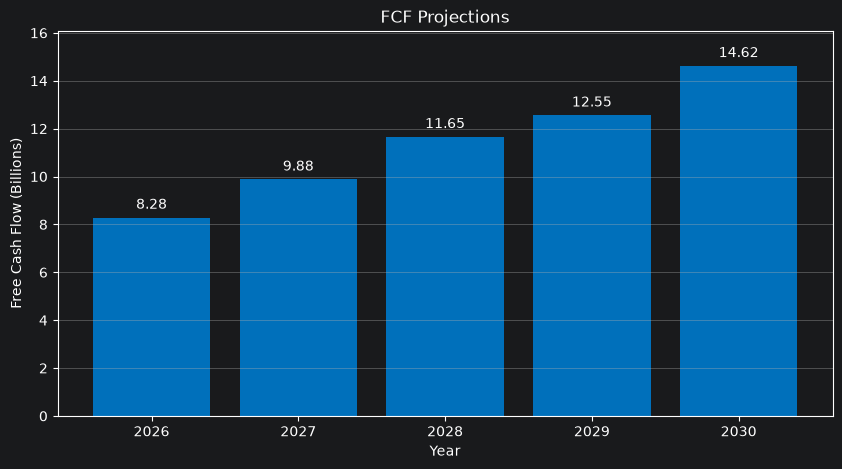

In [20]:
scale, unit = calculate_scale(df_proj["Free Cash Flow"].abs().max())

plt.figure(figsize=(10, 5))

bars = plt.bar(df_proj.index, df_proj["Free Cash Flow"] / scale, color=colors["blue"])

plt.bar_label(bars, fmt=f"%.2f", padding=4)

plt.title("FCF Projections")
plt.xlabel("Year")
plt.ylabel(f"Free Cash Flow ({unit})")

plt.xticks(df_proj.index)
plt.margins(y=0.1)

plt.grid(axis="y")

plt.show()

In [21]:
TV = df_proj["Free Cash Flow"].values[-1] * (1 + TGR) / (WACC - TGR)
pv_TV = TV / (1 + WACC) ** n

In [22]:
Enterprise_Value = np.sum(df_proj["PV Free Cash Flow"]) + pv_TV
Cash = total_cash_and_investments.iloc[-1]
Equity_Value = Enterprise_Value - Debt + Cash

SharesOutstanding = company.get_shares_full().iloc[-1]
Implied_Share_Price = Equity_Value / SharesOutstanding

print(f"Implied Share Price: {Implied_Share_Price:.2f}")

Implied Share Price: 79.09


In [23]:
current_market_price = company.history(period="1d")["Close"].iloc[-1]
margin_of_safety = ((Implied_Share_Price - current_market_price) / Implied_Share_Price) * 100

print(f"Margin of Safety: {margin_of_safety:.2f}%")

Margin of Safety: 11.04%
